# Nail Anemia Classification  Data Preparation Module (Notebook 3)

Prepares a binary anemia/non-anemia fingernail dataset  the third
nail-category dataset, feeding into the multi-site (nail + palm + eye
+ oral + tongue) anemia fusion model.

**Dataset:** [Dataset of human skin and fingernails images for non-invasive
haemoglobin level assessment  Figshare](https://springernature.figshare.com/articles/dataset/Dataset_of_human_skin_and_fingernails_images_for_non-invasive_haemoglobin_level_assessment/25867432)
(Yakimov et al., Scientific Data, 2024  250 patients, clinical Hb
measurements, mobile-camera nail photos)

## What this notebook does

1. **Load metadata**  `metadata.csv` has per-patient Hb level (g/L)
   and nail bounding boxes (3 per patient: index/middle/ring finger).
   No pre-made anemic/non-anemic label  derived one using the
   **Hb < 120 g/L** threshold (matches the original paper's own
   reported low-Hb cutoff: 69/250 patients).

2. **Extract nail crops**  cropped each of the 3 nail regions per
   patient from the full hand photo using the provided bounding boxes,
   with 25% padding added (native crops were very small, ~58x51px,
   so padding + `INTER_CUBIC` upsampling to 224x224 improved quality).
   **250 patients x 3 fingers = 750 nail images.**

3. **Artifact check**  0% black-border/rotation artifact in both
   classes (clean clinical photography, no export artifacts).

4. **Class distribution:** 207 Anemic, 543 Non_Anemic (imbalance ~2.6x
    will need class weighting at training time).

**Important for training:** each patient contributes 3 crops. Any
train/val/test split MUST be done by `patient_id`, not by individual
crop, or the same patient's fingers could leak across splits.

**Final output:** `df` dataframe (750 images) with `final_path` column
at `/kaggle/working/nail_hb_crops_v2/`, saved as
`/kaggle/working/nail_hb_final_clean.csv`.

In [2]:
#Step_1: Loading dataset from input dir
DATASET_META = {
    "dataset_name": "Human Skin & Fingernails Hb Dataset (Figshare)",
    "dataset_url": "https://springernature.figshare.com/articles/dataset/Dataset_of_human_skin_and_fingernails_images_for_non-invasive_haemoglobin_level_assessment/25867432",
    "kaggle_slug": "shahrozkhalid11/anemia-dataset-v2",
    "kaggle_input_path": "/kaggle/input/datasets/shahrozkhalid11/anemia-dataset-v2",
    "surface": "Nail",
    "target_classes": ["Anemic", "Non_Anemic"]
}

from pathlib import Path
DATASET_ROOT = Path(DATASET_META["kaggle_input_path"])

if not DATASET_ROOT.exists():
    DATASET_ROOT = Path(f"/kaggle/input/{DATASET_META['kaggle_slug'].split('/')[-1]}")

assert DATASET_ROOT.exists(), (
    f"Dataset not found at: {DATASET_META['kaggle_input_path']}\n"
    f"Please attach the dataset from: {DATASET_META['dataset_url']}"
)

print(f"Verified: {DATASET_META['dataset_name']}")
print(f"Mounted Path: {DATASET_ROOT}")

Verified: Human Skin & Fingernails Hb Dataset (Figshare)
Mounted Path: /kaggle/input/datasets/shahrozkhalid11/anemia-dataset-v2


In [3]:
#Step_2 : See folder structure
for p in sorted(DATASET_ROOT.rglob("*"))[:20]:
    print(p.relative_to(DATASET_ROOT))

metadata.csv
photo
photo/1.jpg
photo/100.jpg
photo/102.jpg
photo/103.jpg
photo/104.jpg
photo/105.jpg
photo/106.jpg
photo/107.jpg
photo/109.jpg
photo/11.jpg
photo/110.jpg
photo/111.jpg
photo/12.jpg
photo/120.jpg
photo/121.jpg
photo/123.jpg
photo/124.jpg
photo/125.jpg


In [5]:
#Step_3: See metadata of dataset 
import pandas as pd

meta = pd.read_csv(DATASET_ROOT / "metadata.csv")
print(f"Total patients: {len(meta)}")
print(f"\nColumns: {list(meta.columns)}")
print(meta.head())
print(f"\nHB_LEVEL_GperL stats:")
print(meta["HB_LEVEL_GperL"].describe() if "HB_LEVEL_GperL" in meta.columns else "column name might differ, see printed columns above")

Total patients: 250

Columns: ['PATIENT_ID', 'MEASUREMENT_DATE', 'HB_LEVEL_GperL', 'NAIL_BOUNDING_BOXES', 'SKIN_BOUNDING_BOXES']
   PATIENT_ID                  MEASUREMENT_DATE  HB_LEVEL_GperL  \
0           1  14b0293a34344cc4fba0fa39d5370c52           134.0   
1           2  14b0293a34344cc4fba0fa39d5370c52           108.0   
2           5  14b0293a34344cc4fba0fa39d5370c52            84.0   
3           6  14b0293a34344cc4fba0fa39d5370c52           138.0   
4           7  14b0293a34344cc4fba0fa39d5370c52           119.0   

                                 NAIL_BOUNDING_BOXES  \
0  [[251, 447, 302, 505], [123, 429, 183, 483], [...   
1  [[236, 503, 281, 556], [148, 457, 195, 514], [...   
2  [[244, 508, 277, 562], [183, 448, 220, 505], [...   
3  [[311, 456, 363, 521], [182, 408, 237, 471], [...   
4  [[29, 513, 78, 556], [119, 435, 165, 479], [18...   

                                 SKIN_BOUNDING_BOXES  
0  [[267, 586, 324, 627], [148, 556, 200, 614], [...  
1  [[252, 612, 294, 6

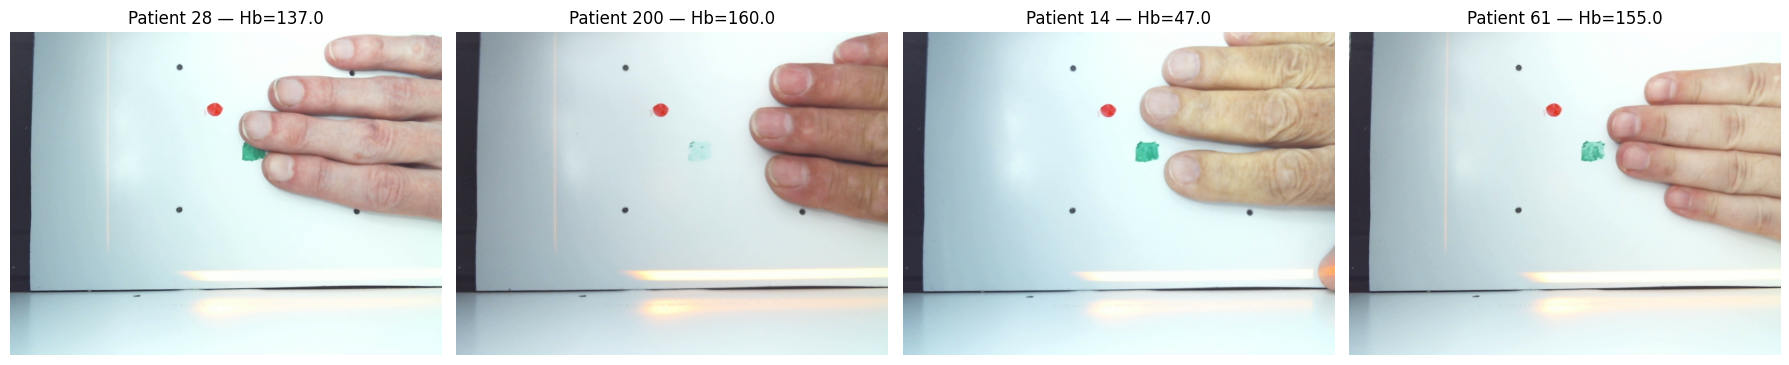

In [6]:
#Step: Showing randomly original dataset pics
import matplotlib.pyplot as plt
import cv2

sample_patients = meta.sample(4, random_state=None)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (_, row) in zip(axes, sample_patients.iterrows()):
    photo_path = DATASET_ROOT / "photo" / f"{row['PATIENT_ID']}.jpg"
    img = cv2.imread(str(photo_path))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"Patient {row['PATIENT_ID']} — Hb={row['HB_LEVEL_GperL']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
#Step_4: Label patients + parse bounding boxes
import ast

meta["class_name"] = meta["HB_LEVEL_GperL"].apply(lambda hb: "Anemic" if hb < 120 else "Non_Anemic")
print(meta["class_name"].value_counts())

# NAIL_BOUNDING_BOXES is stored as a string representation of a list of lists — parse it
meta["nail_boxes"] = meta["NAIL_BOUNDING_BOXES"].apply(ast.literal_eval)
print(f"\nExample parsed boxes (patient {meta.iloc[0]['PATIENT_ID']}): {meta.iloc[0]['nail_boxes']}")
print(f"Number of nail boxes for this patient: {len(meta.iloc[0]['nail_boxes'])}")

# check how many nail boxes each patient has (should mostly be 3 - index/middle/ring finger)
box_counts = meta["nail_boxes"].apply(len)
print(f"\nDistribution of nail-box counts per patient:")
print(box_counts.value_counts())

class_name
Non_Anemic    181
Anemic         69
Name: count, dtype: int64

Example parsed boxes (patient 1): [[251, 447, 302, 505], [123, 429, 183, 483], [49, 459, 104, 520]]
Number of nail boxes for this patient: 3

Distribution of nail-box counts per patient:
nail_boxes
3    250
Name: count, dtype: int64


In [8]:
#Step_5 : Extract individual nail crops from bounding boxes
import cv2
import numpy as np
from pathlib import Path

CROP_DIR = Path("/kaggle/working/nail_hb_crops")
FINGER_NAMES = ["index", "middle", "ring"]

records = []
missing_photos = 0

for _, row in meta.iterrows():
    photo_path = DATASET_ROOT / "photo" / f"{row['PATIENT_ID']}.jpg"
    if not photo_path.exists():
        missing_photos += 1
        continue

    img = cv2.imread(str(photo_path))
    if img is None:
        missing_photos += 1
        continue

    cls_dir = CROP_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)

    for i, box in enumerate(row["nail_boxes"]):
        top, left, bottom, right = box
        crop = img[top:bottom, left:right]
        if crop.size == 0:
            continue
        finger = FINGER_NAMES[i] if i < len(FINGER_NAMES) else f"finger{i}"
        fname = f"{row['PATIENT_ID']}_{finger}.jpg"
        dest_path = cls_dir / fname
        cv2.imwrite(str(dest_path), crop)

        records.append({
            "patient_id": row["PATIENT_ID"],
            "finger": finger,
            "path": str(dest_path),
            "filename": fname,
            "class_name": row["class_name"],
            "hb_level": row["HB_LEVEL_GperL"]
        })

df = pd.DataFrame(records)
print(f"Missing/unreadable photos: {missing_photos}")
print(f"Total nail crops extracted: {len(df)}")
print(df["class_name"].value_counts())

Missing/unreadable photos: 0
Total nail crops extracted: 750
class_name
Non_Anemic    543
Anemic        207
Name: count, dtype: int64


In [9]:
#Step_6: Re-extract crops with margin, then resize
CROP_DIR = Path("/kaggle/working/nail_hb_crops_v2")
IMG_SIZE = (224, 224)
MARGIN_FRAC = 0.25  # 25% padding around each box

records = []
for _, row in meta.iterrows():
    photo_path = DATASET_ROOT / "photo" / f"{row['PATIENT_ID']}.jpg"
    img = cv2.imread(str(photo_path))
    h, w = img.shape[:2]

    cls_dir = CROP_DIR / row["class_name"]
    cls_dir.mkdir(parents=True, exist_ok=True)

    for i, box in enumerate(row["nail_boxes"]):
        top, left, bottom, right = box
        box_h, box_w = bottom - top, right - left
        pad_h, pad_w = int(box_h * MARGIN_FRAC), int(box_w * MARGIN_FRAC)

        top_p = max(0, top - pad_h)
        left_p = max(0, left - pad_w)
        bottom_p = min(h, bottom + pad_h)
        right_p = min(w, right + pad_w)

        crop = img[top_p:bottom_p, left_p:right_p]
        if crop.size == 0:
            continue
        resized = cv2.resize(crop, IMG_SIZE, interpolation=cv2.INTER_CUBIC)

        finger = FINGER_NAMES[i] if i < len(FINGER_NAMES) else f"finger{i}"
        fname = f"{row['PATIENT_ID']}_{finger}.jpg"
        dest_path = cls_dir / fname
        cv2.imwrite(str(dest_path), resized)

        records.append({
            "patient_id": row["PATIENT_ID"], "finger": finger,
            "path": str(dest_path), "filename": fname,
            "class_name": row["class_name"], "hb_level": row["HB_LEVEL_GperL"],
            "crop_size": f"{box_w}x{box_h}"
        })

df = pd.DataFrame(records)
print(f"Total crops: {len(df)}")
print(df["class_name"].value_counts())

Total crops: 750
class_name
Non_Anemic    543
Anemic        207
Name: count, dtype: int64


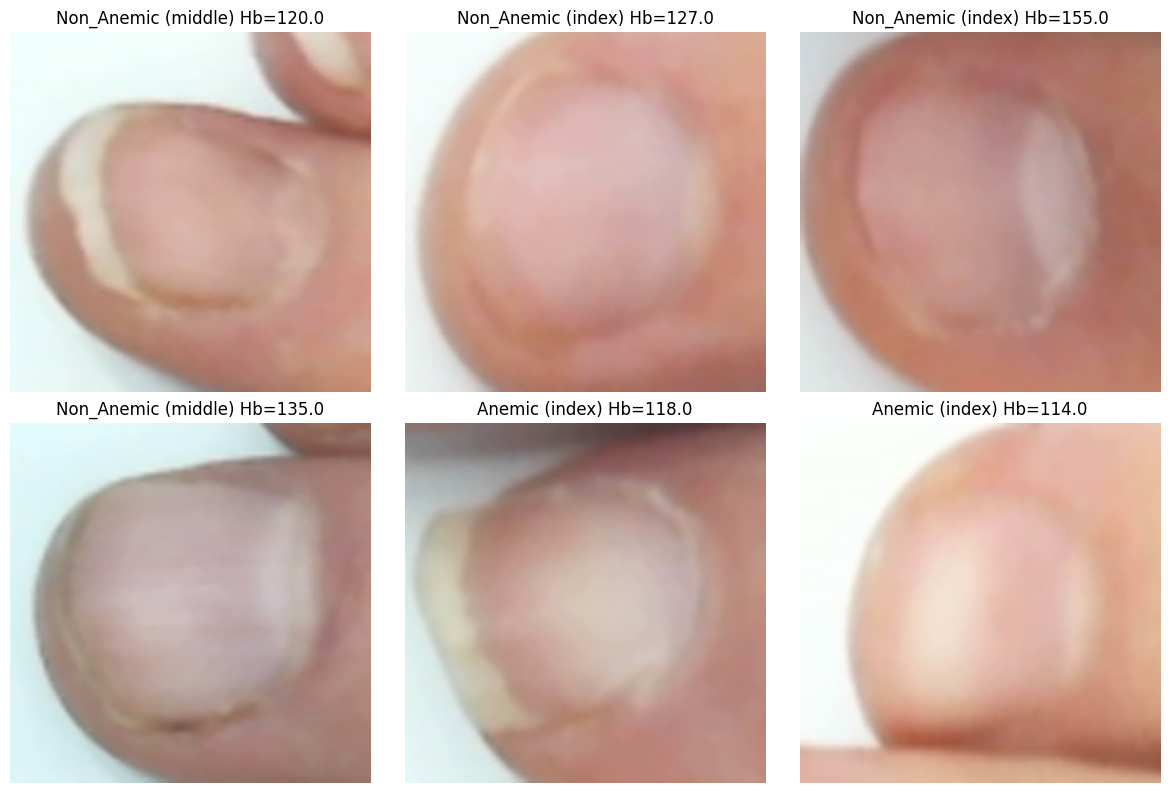

In [10]:
#Step_7: Visual check of a few crops
import matplotlib.pyplot as plt

sample = df.sample(6, random_state=1)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = cv2.imread(row["path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{row["class_name"]} ({row["finger"]}) Hb={row["hb_level"]}')
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
#Step_8: Artifact check (consistency) 
def has_box_artifact(img_path, dark_thresh=15, border_frac=0.05):
    img = cv2.imread(str(img_path))
    if img is None:
        return False
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    bh, bw = max(1, int(h * border_frac)), max(1, int(w * border_frac))
    top, bottom = gray[:bh, :], gray[-bh:, :]
    left, right = gray[:, :bw], gray[:, -bw:]
    border_pixels = np.concatenate([top.ravel(), bottom.ravel(), left.ravel(), right.ravel()])
    return (border_pixels < dark_thresh).mean() > 0.5

df["box_artifact"] = df["path"].apply(has_box_artifact)
summary = df.groupby("class_name")["box_artifact"].agg(["sum", "count"])
summary["pct"] = (summary["sum"] / summary["count"] * 100).round(1)
print(summary)

            sum  count  pct
class_name                 
Anemic        0    207  0.0
Non_Anemic    0    543  0.0


In [12]:
# Step_9 : Sanity check: confirm 3 crops per patient always share patient_id (for future split-by-patient)
print(df.groupby("patient_id").size().value_counts())
print(f"\nUnique patients: {df['patient_id'].nunique()}, Total crops: {len(df)}")

3    250
Name: count, dtype: int64

Unique patients: 250, Total crops: 750


In [13]:
#Step_10: Final summary
df["final_path"] = df["path"]  # already at target size/location

print(f"Final dataset: {len(df)} nail crops from {df['patient_id'].nunique()} patients")
print(df["class_name"].value_counts())
print(f"\nImbalance ratio: {df['class_name'].value_counts().max() / df['class_name'].value_counts().min():.2f}x")
print(f"\nHb level range: {df['hb_level'].min()} - {df['hb_level'].max()} g/L")
print(f"Anemia threshold used: Hb < 120 g/L")

output_path = "/kaggle/working/nail_hb_final_clean.csv"
df.to_csv(output_path, index=False)
print(f"\nSaved -> {output_path}")

Final dataset: 750 nail crops from 250 patients
class_name
Non_Anemic    543
Anemic        207
Name: count, dtype: int64

Imbalance ratio: 2.62x

Hb level range: 44.0 - 169.0 g/L
Anemia threshold used: Hb < 120 g/L

Saved -> /kaggle/working/nail_hb_final_clean.csv


In [14]:
#Step_11: Full detailed table  everything we did, per nail-crop record
display_df = df[["patient_id", "finger", "hb_level", "class_name",
                  "box_artifact", "filename", "final_path"]].copy()
display_df = display_df.sort_values(["patient_id", "finger"]).reset_index(drop=True)

print(f"Full dataset table ({len(display_df)} rows, {display_df['patient_id'].nunique()} unique patients):\n")
pd.set_option("display.max_colwidth", 60)
display_df

Full dataset table (750 rows, 250 unique patients):



,patient_id,finger,hb_level,class_name,box_artifact,filename,final_path
0,1,index,134.0,Non_Anemic,False,1_index.jpg,/kaggle/working/nail_hb_crops_v2/Non_Anemic/1_index.jpg
1,1,middle,134.0,Non_Anemic,False,1_middle.jpg,/kaggle/working/nail_hb_crops_v2/Non_Anemic/1_middle.jpg
2,1,ring,134.0,Non_Anemic,False,1_ring.jpg,/kaggle/working/nail_hb_crops_v2/Non_Anemic/1_ring.jpg
3,2,index,108.0,Anemic,False,2_index.jpg,/kaggle/working/nail_hb_crops_v2/Anemic/2_index.jpg
4,2,middle,108.0,Anemic,False,2_middle.jpg,/kaggle/working/nail_hb_crops_v2/Anemic/2_middle.jpg
...,...,...,...,...,...,...,...
745,341,middle,50.0,Anemic,False,341_middle.jpg,/kaggle/working/nail_hb_crops_v2/Anemic/341_middle.jpg
746,341,ring,50.0,Anemic,False,341_ring.jpg,/kaggle/working/nail_hb_crops_v2/Anemic/341_ring.jpg
747,342,index,133.0,Non_Anemic,False,342_index.jpg,/kaggle/working/nail_hb_crops_v2/Non_Anemic/342_index.jpg
748,342,middle,133.0,Non_Anemic,False,342_middle.jpg,/kaggle/working/nail_hb_crops_v2/Non_Anemic/342_middle.jpg


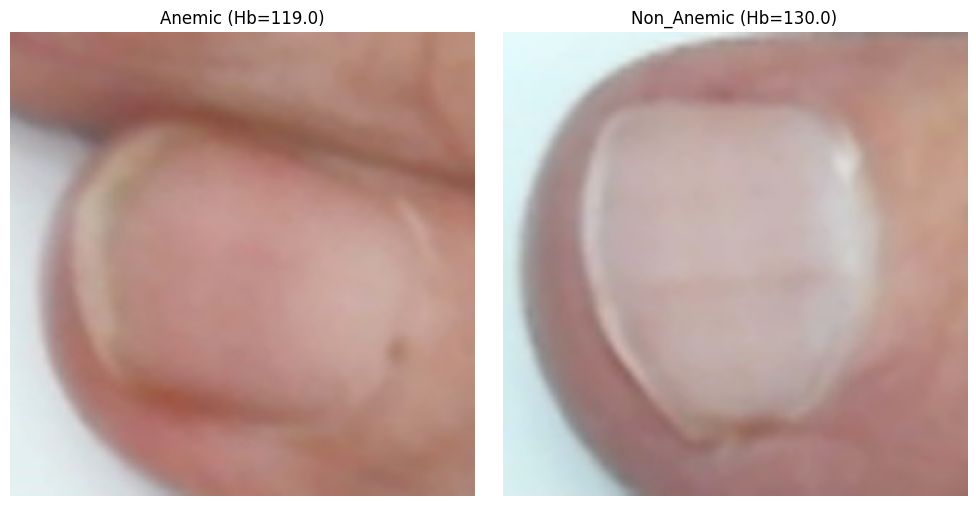

In [17]:
#Step_12: Random sample per class
classes = sorted(df["class_name"].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(5 * len(classes), 5))

for ax, cls in zip(axes, classes):
    row = df[df["class_name"] == cls].sample(1).iloc[0]
    img = cv2.imread(row["final_path"])
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'{cls} (Hb={row["hb_level"]})')
    ax.axis("off")

plt.tight_layout()
plt.show()